# Rfam gold-standard set + held-out-family generalization

**Question:** does the signal/noise representation generalize to *structured RNA families it never saw in training*? The deployed classifier trains on GENCODE structured ncRNA (tRNA/miRNA/snoRNA/snRNA/misc_RNA/scaRNA). Rfam seed alignments are the canonical curated 'definitely structured RNA' -- each family is a set of homologs sharing a consensus secondary structure ([Rfam 15, NAR 2025](https://academic.oup.com/nar/article/53/D1/D258/7907559)).

**Two evaluations:**
1. **Held-out-family CV** -- split Rfam families into folds; train signal/noise logreg on some families, test on *unseen* families. Compare to a random (in-distribution) split to expose the generalization gap. RiNALMo vs RNA-FM head-to-head. This is the metric RiNALMo's 'generalizes to unseen RNA' pitch is about.
2. **Deployment probe** -- score every Rfam family with the *already-shipped* `logreg_noise_model_rinalmo.json` at its deployed threshold. Does a classifier trained only on GENCODE biotypes recognize curated Rfam families? Per-type recall breakdown.

Windows: central <=72 nt of each seed sequence, mean-pooled through the global per-token PCA (k=16) -- matching the deployed feature. Negatives: dinucleotide shuffles (composition-matched, structure destroyed) and intergenic.

In [1]:
import os
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')
import sys, gzip, random, time, re
from pathlib import Path
from collections import Counter, defaultdict
import numpy as np
import torch

REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from modules.model_registry import load_model, get_logreg_path, get_island_scan_params
from modules.global_PCA.apply_pca import apply_pca, load_pca
from modules.logreg_signal_noise.apply_logreg import load_logreg_model, score_embeddings
from pyrion import TwoBitAccessor

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
SEED = 42
WINDOW = 72
SEED_GZ = REPO_ROOT / 'input_data/supply/rfam/Rfam.seed.gz'
TWOBIT = REPO_ROOT / 'input_data/2bit/hg38.2bit'
print('device:', device, '| seed file exists:', SEED_GZ.exists())

device: mps | seed file exists: True


In [2]:
# Parse Rfam seed (Stockholm). Per family: accession, id, type (TP), ungapped sequences.
def parse_rfam_seed(path):
    fams = {}
    acc = idd = tp = None
    seqs = defaultdict(str)
    with gzip.open(path, 'rt', encoding='latin-1') as f:
        for line in f:
            line = line.rstrip('\n')
            if line.startswith('#=GF AC'): acc = line.split()[2]
            elif line.startswith('#=GF ID'): idd = line.split()[2]
            elif line.startswith('#=GF TP'): tp = line.split(None, 2)[2].strip()
            elif line == '//':
                if acc:
                    ung = []
                    for s in seqs.values():
                        u = s.upper().replace('T', 'U').replace('.', '').replace('-', '')
                        u = ''.join(u.split())
                        if u and set(u) <= set('ACGU'):
                            ung.append(u)
                    if ung:
                        fams[acc] = {'id': idd, 'tp': tp, 'seqs': ung}
                acc = idd = tp = None; seqs = defaultdict(str)
            elif line and not line.startswith('#'):
                parts = line.split(None, 1)
                if len(parts) == 2:
                    seqs[parts[0]] += parts[1]
    return fams

t0 = time.time()
fams = parse_rfam_seed(SEED_GZ)
print(f'parsed {len(fams)} families with >=1 pure-ACGU seq ({time.time()-t0:.0f}s)')

# top-level type breakdown
top_tp = Counter(v['tp'].split(';')[0].strip() if v['tp'] else 'NA' for v in fams.values())
print('\ntop-level TP:', dict(top_tp.most_common()))
nseq = np.array([len(v['seqs']) for v in fams.values()])
medlen = np.array([int(np.median([len(s) for s in v['seqs']])) for v in fams.values()])
print('\nseqs/family  p25/50/75/90:', np.percentile(nseq, [25,50,75,90]).astype(int).tolist())
print('median len   p10/50/90:', np.percentile(medlen, [10,50,90]).astype(int).tolist())

parsed 4227 families with >=1 pure-ACGU seq (0s)

top-level TP: {'Gene': 3655, 'Cis-reg': 555, 'Intron': 17}

seqs/family  p25/50/75/90: [3, 5, 16, 43]
median len   p10/50/90: [60, 87, 191]


In [3]:
# Select families: enough sequences for a stable per-family estimate, sensible length.
MIN_SEQS = 25
MAX_PER_FAM = 40
N_FAMS = 150
rng = random.Random(SEED)

def subtype(tp):
    parts = [p.strip() for p in (tp or '').split(';') if p.strip()]
    return parts[1] if len(parts) > 1 else (parts[0] if parts else 'NA')

def center_win(seq, w=WINDOW):
    if len(seq) <= w: return seq
    s = (len(seq) - w) // 2
    return seq[s:s+w]

qual = []
for acc, v in fams.items():
    seqs = [s for s in v['seqs'] if len(s) >= 40]
    ml = np.median([len(s) for s in seqs]) if seqs else 0
    if len(seqs) >= MIN_SEQS and 50 <= ml <= 200:
        qual.append(acc)
rng.shuffle(qual)
sel = qual[:N_FAMS]
print(f'{len(qual)} families qualify (>= {MIN_SEQS} seqs, median len 50-200); using {len(sel)}')

# Build windows: up to MAX_PER_FAM per family, central <=72 nt
win_seq, win_fam, win_sub = [], [], []
for acc in sel:
    seqs = [s for s in fams[acc]['seqs'] if len(s) >= 40]
    rng.shuffle(seqs)
    for s in seqs[:MAX_PER_FAM]:
        win_seq.append(center_win(s)); win_fam.append(acc); win_sub.append(subtype(fams[acc]['tp']))
win_fam = np.array(win_fam); win_sub = np.array(win_sub)
print(f'signal windows: {len(win_seq)} from {len(set(win_fam))} families')
print('subtype mix:', dict(Counter(win_sub).most_common(12)))
print('window len p10/50/90:', np.percentile([len(s) for s in win_seq], [10,50,90]).astype(int).tolist())

590 families qualify (>= 25 seqs, median len 50-200); using 150
signal windows: 5454 from 150 families
subtype mix: {np.str_('sRNA'): 1430, np.str_('Cis-reg'): 1123, np.str_('snRNA'): 740, np.str_('miRNA'): 694, np.str_('leader'): 413, np.str_('riboswitch'): 400, np.str_('lncRNA'): 205, np.str_('Gene'): 178, np.str_('antisense'): 80, np.str_('Intron'): 80, np.str_('ribozyme'): 71, np.str_('antitoxin'): 40}
window len p10/50/90: [59, 72, 72]


In [4]:
# Negatives: (a) dinucleotide shuffle of each signal window (composition-matched, structure destroyed),
#            (b) random intergenic 72-nt windows (deployment-like).
def dinuc_shuffle(seq, rng):
    seq = seq.upper()
    if len(seq) < 3: return seq
    nucs = set(seq); last = seq[-1]; first = seq[0]
    for _ in range(100):
        edges = {n: [] for n in nucs}
        for i in range(len(seq) - 1): edges[seq[i]].append(seq[i + 1])
        for n in edges: rng.shuffle(edges[n])
        tree_next = {n: edges[n][-1] for n in edges if n != last and edges[n]}
        ok = all(n in edges and edges[n] for n in nucs if n != last)
        if ok:
            for n in list(tree_next):
                cur, seen = n, set()
                while cur != last:
                    if cur in seen or cur not in tree_next: ok = False; break
                    seen.add(cur); cur = tree_next[cur]
                if not ok: break
        if ok:
            work = {n: list(edges[n]) for n in nucs}; res = [first]; cur = first
            for _ in range(len(seq) - 1): res.append(work[cur].pop(0)); cur = res[-1]
            return ''.join(res)
    a = list(seq); rng.shuffle(a); return ''.join(a)

rng_s = random.Random(SEED + 3)
dinuc_seq = [dinuc_shuffle(s, rng_s) for s in win_seq]

acc2b = TwoBitAccessor(str(TWOBIT))
cs = acc2b.chrom_sizes()
chroms = [c for c in cs if c.startswith('chr') and '_' not in c and c != 'chrM']
rng_n = random.Random(SEED + 1)
inter_seq = []
while len(inter_seq) < len(win_seq):
    c = rng_n.choice(chroms); s = rng_n.randint(0, cs[c] - WINDOW)
    try: q = str(acc2b.fetch(c, s, s + WINDOW)).upper().replace('T', 'U')
    except Exception: continue
    if 'N' not in q and len(q) == WINDOW: inter_seq.append(q)

gc = lambda ss: float(np.mean([(x.count('G')+x.count('C'))/len(x) for x in ss]))
print(f'signal   n={len(win_seq)} GC={gc(win_seq):.3f}')
print(f'dinuc    n={len(dinuc_seq)} GC={gc(dinuc_seq):.3f}  (should match signal)')
print(f'intergen n={len(inter_seq)} GC={gc(inter_seq):.3f}')

signal   n=5454 GC=0.499
dinuc    n=5454 GC=0.499  (should match signal)
intergen n=5454 GC=0.413


In [5]:
# Embed mean-pooled through global PCA (deployed feature): (N, k) per set per model.
def embed_mean_pca(model_name, seqs, batch=64):
    model, tok, extract = load_model(model_name, device)
    pca = load_pca(model_name=model_name)
    vecs = []; t0 = time.time()
    for i in range(0, len(seqs), batch):
        chunk = [s.upper().replace('T', 'U') for s in seqs[i:i+batch]]
        tokens = tok(chunk)
        with torch.no_grad():
            reps = extract(model, tokens)
        for j, s in enumerate(chunk):
            vecs.append(reps[j, 1:1+len(s), :].mean(0).cpu().float().numpy())
        if (i // batch) % 20 == 0:
            print(f'  {model_name}: {i+len(chunk)}/{len(seqs)} ({time.time()-t0:.0f}s)', flush=True)
    del model
    if device.type == 'mps' and hasattr(torch.mps, 'empty_cache'): torch.mps.empty_cache()
    return np.asarray(apply_pca(np.array(vecs), pca_model=pca))

SETS = {'signal': win_seq, 'dinuc': dinuc_seq, 'intergenic': inter_seq}
emb = {}   # model -> {set: (N,k)}
for mname in ['rinalmo', 'rnafm']:
    emb[mname] = {}
    for sname, seqs in SETS.items():
        print(f'Embedding {mname}/{sname}...')
        emb[mname][sname] = embed_mean_pca(mname, seqs)
    print(f'  {mname}: ' + ', '.join(f'{k}{v.shape}' for k, v in emb[mname].items()))
print('done')

Embedding rinalmo/signal...
  rinalmo: 64/5454 (4s)
  rinalmo: 1344/5454 (33s)
  rinalmo: 2624/5454 (63s)
  rinalmo: 3904/5454 (94s)
  rinalmo: 5184/5454 (124s)
Embedding rinalmo/dinuc...
  rinalmo: 64/5454 (1s)
  rinalmo: 1344/5454 (31s)
  rinalmo: 2624/5454 (62s)
  rinalmo: 3904/5454 (92s)
  rinalmo: 5184/5454 (123s)
Embedding rinalmo/intergenic...
  rinalmo: 64/5454 (1s)
  rinalmo: 1344/5454 (31s)
  rinalmo: 2624/5454 (62s)
  rinalmo: 3904/5454 (93s)
  rinalmo: 5184/5454 (125s)
  rinalmo: signal(5454, 16), dinuc(5454, 16), intergenic(5454, 16)
Embedding rnafm/signal...
  rnafm: 64/5454 (2s)
  rnafm: 1344/5454 (6s)
  rnafm: 2624/5454 (12s)
  rnafm: 3904/5454 (17s)
  rnafm: 5184/5454 (22s)
Embedding rnafm/dinuc...
  rnafm: 64/5454 (0s)
  rnafm: 1344/5454 (5s)
  rnafm: 2624/5454 (10s)
  rnafm: 3904/5454 (15s)
  rnafm: 5184/5454 (19s)
Embedding rnafm/intergenic...
  rnafm: 64/5454 (0s)
  rnafm: 1344/5454 (5s)
  rnafm: 2624/5454 (10s)
  rnafm: 3904/5454 (15s)
  rnafm: 5184/5454 (20s)
  r

In [6]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# Held-out-FAMILY CV: no family appears in both train and test. Compares against a
# random window-level split to expose the in-distribution -> unseen-family gap.
K = 5

def random_cv(P, N):
    X = np.vstack([P, N]); y = np.r_[np.ones(len(P)), np.zeros(len(N))]
    skf = StratifiedKFold(K, shuffle=True, random_state=SEED)
    a = [roc_auc_score(y[te], LogisticRegression(max_iter=1000, class_weight='balanced')
         .fit(X[tr], y[tr]).predict_proba(X[te])[:, 1]) for tr, te in skf.split(X, y)]
    return float(np.mean(a)), float(np.std(a))

def family_cv(P, fam, N):
    famlist = sorted(set(fam)); rng = random.Random(SEED); rng.shuffle(famlist)
    folds = [set(famlist[i::K]) for i in range(K)]
    Nidx = np.arange(len(N)); np.random.RandomState(SEED).shuffle(Nidx)
    Nf = np.array_split(Nidx, K)
    aucs = []
    for i in range(K):
        te_p = np.isin(fam, list(folds[i])); tr_p = ~te_p
        te_n = Nf[i]; tr_n = np.concatenate([Nf[j] for j in range(K) if j != i])
        Xtr = np.vstack([P[tr_p], N[tr_n]]); ytr = np.r_[np.ones(tr_p.sum()), np.zeros(len(tr_n))]
        Xte = np.vstack([P[te_p], N[te_n]]); yte = np.r_[np.ones(te_p.sum()), np.zeros(len(te_n))]
        clf = LogisticRegression(max_iter=1000, class_weight='balanced').fit(Xtr, ytr)
        aucs.append(roc_auc_score(yte, clf.predict_proba(Xte)[:, 1]))
    return float(np.mean(aucs)), float(np.std(aucs))

print(f"{'model':9s}{'negative':12s}{'random-split AUC':>18s}{'held-out-family':>18s}{'gap':>8s}")
print('-' * 65)
cv_res = {}
for mname in ['rinalmo', 'rnafm']:
    P = emb[mname]['signal']
    for neg in ['intergenic', 'dinuc']:
        N = emb[mname][neg]
        r = random_cv(P, N); f = family_cv(P, win_fam, N)
        cv_res[(mname, neg)] = {'random': r, 'family': f}
        print(f'{mname:9s}{neg:12s}{r[0]:>10.3f}+/-{r[1]:.3f}{f[0]:>10.3f}+/-{f[1]:.3f}{r[0]-f[0]:>+8.3f}')

model    negative      random-split AUC   held-out-family     gap
-----------------------------------------------------------------
rinalmo  intergenic       0.927+/-0.001     0.923+/-0.014  +0.004
rinalmo  dinuc            0.736+/-0.011     0.723+/-0.030  +0.013
rnafm    intergenic       0.917+/-0.005     0.912+/-0.011  +0.005
rnafm    dinuc            0.731+/-0.009     0.717+/-0.020  +0.014


In [7]:
# Deployment probe: score Rfam with the ALREADY-SHIPPED classifiers at their deployed thresholds.
# 'Does a classifier trained only on GENCODE structured ncRNA recognize curated Rfam families?'
probe = {}
for mname in ['rinalmo', 'rnafm']:
    clf = load_logreg_model(str(get_logreg_path(mname)))
    thr = get_island_scan_params(mname)['prob_threshold']
    p_sig, _ = score_embeddings(emb[mname]['signal'], model=clf)
    p_int, _ = score_embeddings(emb[mname]['intergenic'], model=clf)
    probe[mname] = {'thr': thr, 'p_sig': p_sig, 'recall': float((p_sig >= thr).mean()),
                    'fpr': float((p_int >= thr).mean())}
    print(f'{mname}: thr={thr}  overall Rfam recall={probe[mname]["recall"]:.3f}  intergenic FPR={probe[mname]["fpr"]:.3f}')

print('\nPer-subtype recall of shipped classifiers on unseen Rfam families:')
subs = [s for s, _ in Counter(win_sub).most_common() if (win_sub == s).sum() >= 40]
print(f"{'subtype':14s}{'n':>6s}{'RiNALMo':>10s}{'RNA-FM':>10s}")
for s in subs:
    m = win_sub == s
    rr = float((probe['rinalmo']['p_sig'][m] >= probe['rinalmo']['thr']).mean())
    rf = float((probe['rnafm']['p_sig'][m] >= probe['rnafm']['thr']).mean())
    print(f'{s:14s}{int(m.sum()):>6d}{rr:>10.2f}{rf:>10.2f}')

rinalmo: thr=0.27  overall Rfam recall=0.836  intergenic FPR=0.423
rnafm: thr=0.25  overall Rfam recall=0.279  intergenic FPR=0.163

Per-subtype recall of shipped classifiers on unseen Rfam families:
subtype            n   RiNALMo    RNA-FM
sRNA            1430      0.85      0.14
Cis-reg         1123      0.83      0.10
snRNA            740      0.73      0.48
miRNA            694      1.00      0.87
leader           413      0.83      0.22
riboswitch       400      0.91      0.10
lncRNA           205      0.47      0.34
Gene             178      0.82      0.03
antisense         80      0.72      0.19
Intron            80      0.89      0.16
ribozyme          71      0.99      0.00
antitoxin         40      0.60      0.00


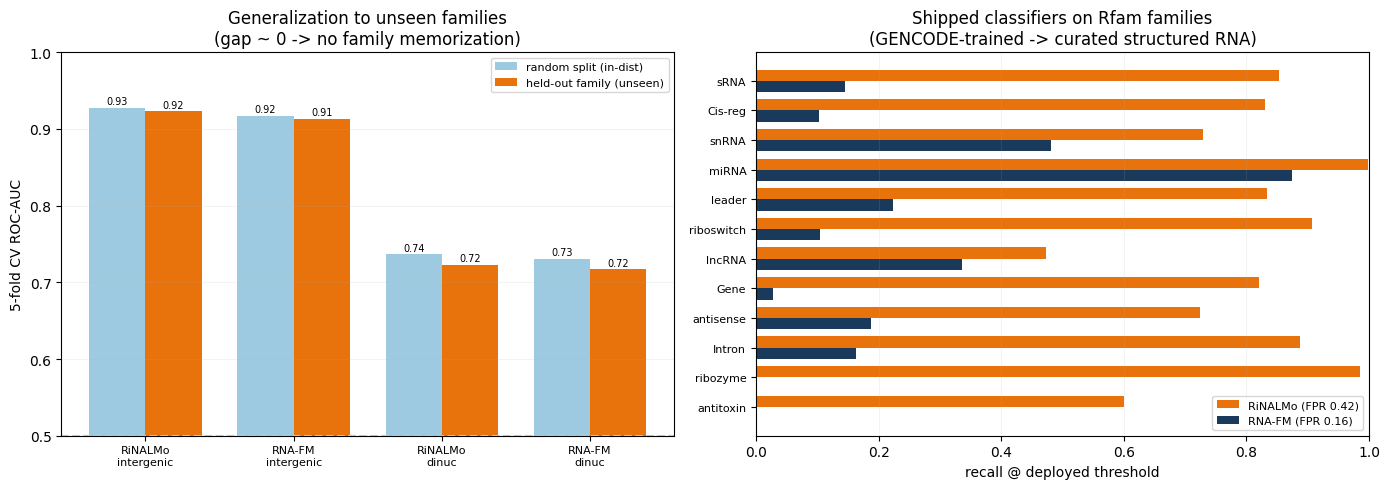

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# (a) random vs held-out-family AUC
labels = ['RiNALMo\nintergenic', 'RNA-FM\nintergenic', 'RiNALMo\ndinuc', 'RNA-FM\ndinuc']
keys = [('rinalmo','intergenic'), ('rnafm','intergenic'), ('rinalmo','dinuc'), ('rnafm','dinuc')]
rand = [cv_res[k]['random'][0] for k in keys]; famv = [cv_res[k]['family'][0] for k in keys]
x = np.arange(len(keys)); w = 0.38
ax[0].bar(x - w/2, rand, w, label='random split (in-dist)', color='#9ecae1')
ax[0].bar(x + w/2, famv, w, label='held-out family (unseen)', color='#e8720c')
ax[0].axhline(0.5, ls='--', c='#ccc'); ax[0].set_ylim(0.5, 1.0)
ax[0].set_xticks(x); ax[0].set_xticklabels(labels, fontsize=8)
ax[0].set_ylabel('5-fold CV ROC-AUC'); ax[0].set_title('Generalization to unseen families\n(gap ~ 0 -> no family memorization)')
ax[0].legend(fontsize=8); ax[0].grid(axis='y', alpha=0.2)
for xi,(r,f) in enumerate(zip(rand,famv)):
    ax[0].text(xi-w/2, r+.005, f'{r:.2f}', ha='center', fontsize=7); ax[0].text(xi+w/2, f+.005, f'{f:.2f}', ha='center', fontsize=7)

# (b) per-subtype recall of shipped classifiers
sr = [float((probe['rinalmo']['p_sig'][win_sub==s] >= probe['rinalmo']['thr']).mean()) for s in subs]
fr = [float((probe['rnafm']['p_sig'][win_sub==s] >= probe['rnafm']['thr']).mean()) for s in subs]
y = np.arange(len(subs))
ax[1].barh(y - w/2, sr, w, label=f"RiNALMo (FPR {probe['rinalmo']['fpr']:.2f})", color='#e8720c')
ax[1].barh(y + w/2, fr, w, label=f"RNA-FM (FPR {probe['rnafm']['fpr']:.2f})", color='#1a3a5c')
ax[1].set_yticks(y); ax[1].set_yticklabels(subs, fontsize=8); ax[1].invert_yaxis()
ax[1].set_xlabel('recall @ deployed threshold'); ax[1].set_xlim(0, 1)
ax[1].set_title('Shipped classifiers on Rfam families\n(GENCODE-trained -> curated structured RNA)')
ax[1].legend(fontsize=8, loc='lower right'); ax[1].grid(axis='x', alpha=0.2)
plt.tight_layout(); plt.show()

## Summary

Gold-standard set: **150 Rfam seed families** (>=25 seqs each, median len 50-200), 5454 windows -- a far broader, curated structured-RNA set than GENCODE, including RNA types the deployed classifier never trained on (bacterial sRNA, riboswitches, leaders, ribozymes, introns, antitoxins). Feature = central <=72 nt, mean-pooled through the global per-token PCA (k=16), matching deployment.

### 1. Held-out-family generalization -- essentially free
The gap between a random (in-distribution) split and holding out **entire families** is negligible (<=0.014 AUC) for both models and both negatives:

| | random split | held-out family | gap |
|---|---|---|---|
| RiNALMo vs intergenic | 0.927 | **0.923** | +0.004 |
| RNA-FM vs intergenic | 0.917 | **0.912** | +0.005 |
| RiNALMo vs dinuc-shuffle | 0.736 | **0.723** | +0.013 |
| RNA-FM vs dinuc-shuffle | 0.731 | **0.717** | +0.014 |

The classifier is **not memorizing families** -- it detects structure that transfers to unseen RNA families. This validates the 'generalizes to unseen structured RNA' premise. RiNALMo and RNA-FM are near-identical (RiNALMo marginally ahead), consistent with the finding-step conclusion that they tie on per-window discrimination.

**Structure vs composition on the broad set:** the dinuc-shuffle AUC is 0.72 here vs ~0.92 in the composition-confound benchmark on canonical compact ncRNA. Both > 0.5 (real structure signal), but the margin scales with how structured the family actually is -- diverse Rfam families (leaders, antitoxins, lncRNA) are harder to distinguish from their composition-matched shuffles than a tRNA cloverleaf is.

### 2. Deployment probe -- shipped classifier recognizes unseen RNA types
The **already-shipped** RiNALMo classifier (trained only on GENCODE structured ncRNA) recalls unseen Rfam families at **0.836 overall**, including types it never saw: riboswitch 0.91, ribozyme 0.99, bacterial sRNA 0.85, intron 0.89, leader 0.83. lncRNA is lowest (0.47) -- consistent with lncRNA being weakly structured, which is exactly why it is the *application domain* (rare islands), not a training positive. **Caveat:** this is at RiNALMo's permissive deployed threshold (intergenic FPR 0.42); recall must be read alongside FPR.

The shipped RNA-FM classifier operates at a much more conservative point (recall 0.28, FPR 0.16) -- but it is a different artifact (`logreg_noise_model.json`, older calibration), so the probe's RiNALMo>>RNA-FM gap reflects **deployment calibration**, not model capability. The fair capability comparison is the held-out-family CV above, where the two are equal. An FPR-matched probe would be needed to compare them on this task directly.

### Takeaways
- The signal/noise representation genuinely generalizes to unseen structured-RNA families (gap ~0) -- a far more meaningful validation than in-distribution AUC.
- Structure detection is real but its strength tracks family structuredness; loosely-structured families (and lncRNA) are inherently harder, which is expected and defines where the pipeline's island-finding is hard.
- The shipped RiNALMo finding-classifier is a broad, permissive structured-RNA detector; consider an FPR-matched RiNALMo-vs-RNA-FM probe and possibly a stricter threshold if precision matters more than recall downstream.